In [6]:
# Import necessary python modules here
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [19]:
# Import the dataset
url = 'https://raw.githubusercontent.com/MaharLeika18/Datasets/refs/heads/main/Sample_Superstore.csv'
df = pd.read_csv(url, index_col=0)

display(df.head(5))

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
# Clean the dataset
# -------------------------------------------------------------------------------

# Handle duplicates
    # Check for duplicate rows, print only true vals
display(df[df.duplicated(keep=False)])
display(df.duplicated(keep=False).sum())

    # Remove duplicates
df.drop_duplicates(inplace=True)

# Drop irrelevant data
    # Drop country since all rows feature the same value for this column: U.S.
df.drop(columns="Country", inplace=True)

# Inspect dataframe
display(df.head(5))

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,
3406,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Home Office,United States,Columbus,Ohio,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
3407,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Home Office,United States,Columbus,Ohio,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


np.int64(2)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,
1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
# Fix data types
    # Date Columns set, normalize delimiters first before converting to datetime
df['Order Date'] = df['Order Date'].str.replace("-", "/", regex=False)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y',errors='coerce')

df['Ship Date'] = df['Ship Date'].str.replace("-", "/", regex=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y', errors='coerce')

    # Numeric Columns set
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

    # Categorical Columns set
df['Region'] = df['Region'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Sub-Category'] = df['Sub-Category'].astype('category')


In [ ]:
# Handle missing values
    # Inspect missing values to determine if there is a significant amount
display(df[df.isna().any(axis=1)])
df.isna().sum()

# No missing values, imputation not needed
# Feature Engineering
df['Order Date (Month)'] = df['Order Date'].dt.to_period('M')
df['Profit Margin'] = df['Profit'] / df['Sales'] * 100
df['YearQuarter'] = df['Order Date (Month)'].dt.to_timestamp().dt.to_period('Q')

# Feature Aggregation
sales_by_region = (df.groupby('Region')['Sales'].sum().reset_index())

monthly_revenue = (df.groupby(pd.Grouper(key='Order Date (Month)'))['Sales'].sum().reset_index())
monthly_revenue = monthly_revenue.sort_values('Order Date (Month)')
quarterly_revenue = df.groupby('YearQuarter')['Sales'].sum().reset_index()
quarterly_revenue = quarterly_revenue.sort_values('YearQuarter')
quarterly_revenue['QuarterLabel'] = quarterly_revenue['YearQuarter'].astype(str).str.replace('Q', ' - Q')
avg_profit_by_product = (df.groupby('Product Name')['Profit'].mean().reset_index())


# Inspect dataframes
display(df.head(5))
display(sales_by_region)
display(monthly_revenue.head(5))
display(quarterly_revenue.head(5))
display(avg_profit_by_product.head(5))

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,


C:\Users\Arrcann\AppData\Local\Temp\ipykernel_18120\1125767913.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_region = (df.groupby('Region')['Sales'].sum().reset_index())


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Date (Month),Profit Margin,YearQuarter
Row ID,,,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11,16.00,2016Q4
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11,30.00,2016Q4
3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06,47.00,2016Q2
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10,-40.00,2015Q4
5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10,11.25,2015Q4


,Region,Sales
0,Central,501239.8908
1,East,678499.8680
2,South,391721.9050
3,West,725457.8245


,Order Date (Month),Sales
46,2014-01,14236.8950
45,2014-02,4519.8920
34,2014-03,55691.0090
41,2014-04,28013.9730
8,2014-05,23648.2870
3,2014-06,34595.1276
39,2014-07,33946.3930
9,2014-08,27909.4685
30,2014-09,81777.3508
18,2014-10,31453.3930


,Product Name,Profit
0,"""While you Were Out"" Message Book, One Form pe...",3.462667
1,"#10 Gummed Flap White Envelopes, 100/Box",4.191950
2,#10 Self-Seal White Envelopes,13.030750
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",31.877257
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",11.528060
...,...,...
1845,iKross Bluetooth Portable Keyboard + Cell Phon...,23.128800
1846,iOttie HLCRIO102 Car Mount,-2.398800
1847,iOttie XL Car Mount,-25.187400
1848,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,24.466400


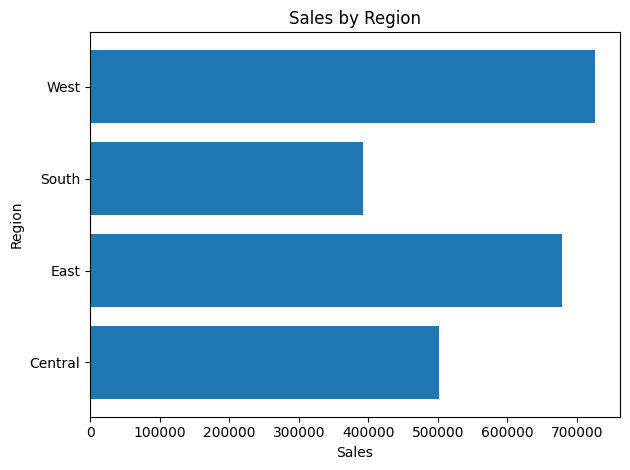

In [ ]:
# Create bar chart - Sales by Region
plt.figure()
plt.barh(sales_by_region['Region'], sales_by_region['Sales'])
plt.xlabel('Sales')
plt.ylabel('Region')
plt.title('Sales by Region')
plt.tight_layout()
plt.show()

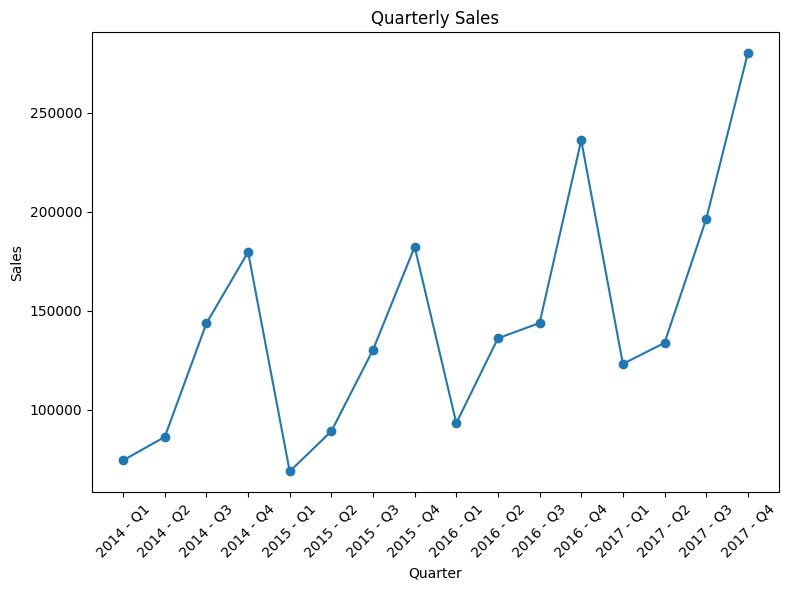

In [12]:
# Create line chart - Quarterly Sales
# Create a nicely formatted quarter label

# Plot using the new labels
plt.figure(figsize=(8,6))
plt.plot(quarterly_revenue['YearQuarter'].astype(str), quarterly_revenue['Sales'], marker='o')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.title('Quarterly Sales')
plt.xticks(ticks=range(len(quarterly_revenue)), 
           labels=quarterly_revenue['QuarterLabel'], rotation=45)
plt.tight_layout()
plt.show()